# Un bosque perturbado tarda una década en soltar el 82 % de su calor extra

Un bosque europeo que se quemó, se taló o se comieron los escarabajos está **1,70 °C más caliente** en verano que el bosque intacto que tiene al lado. Ese número es de este paper. Lo que nadie había medido a escala continental es cuánto tarda ese calor extra en irse.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Su et al. (2026), *Disturbance characteristics and forest properties regulate surface warming and recovery across Europe* — Nature Geoscience
**DOI:** [10.1038/s41561-026-02071-5](https://doi.org/10.1038/s41561-026-02071-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-25-bosques-perturbados-calor-europa/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/hCaP33FXDxA)

## Qué midieron

El equipo cruzó dos cosas que existían por separado: las temperaturas de superficie de verano que el satélite Landsat lleva décadas registrando sobre Europa, y el European Forest Disturbance Atlas, un inventario continental de dónde y cuándo se perturbó cada pedazo de bosque.

La comparación es espacial: cada píxel perturbado contra el bosque **no perturbado que tiene entre 100 y 500 metros de distancia**. Ese anillo es la referencia conservadora del estudio — lo bastante cerca para compartir clima y suelo, lo bastante lejos para no estar contaminado por el borde del claro.

Dos advertencias que valen para todo lo que sigue. La primera: esto es teledetección observacional, nadie quemó un bosque para ver qué pasaba. La segunda: el satélite mide la temperatura de la **superficie**, no la del aire que respiraríamos ahí parados.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANOMALIA_PAPER_C   = 1.70      # °C del abstract: perturbado vs bosque intacto a 100-500 m
AGENTE_FOCO        = 'Insect'  # 'Insect' | 'Fire' | 'Harvest'
TOP_N_PREDICTORES  = 6         # cuántos predictores mostrar en la gráfica de contribuciones
FUENTE = 'Fuente: Su et al. (2026), Nature Geoscience | Datos: Figshare (Extended Data)'

COLOR_DATOS      = '#2563EB'   # azul CaM
COLOR_ALERTA     = '#DC2626'   # rojo
COLOR_SECUNDARIO = '#059669'   # emerald
COLOR_REFERENCIA = '#D97706'   # amber
COLOR_CONTEXTO   = '#BBBBBB'   # gris

COLOR_AGENTE = {'Insect': COLOR_SECUNDARIO, 'Fire': COLOR_ALERTA, 'Harvest': COLOR_REFERENCIA}
NOMBRE_AGENTE = {'Insect': 'Insectos', 'Fire': 'Incendio', 'Harvest': 'Tala'}

# Umbrales de meseta reportados en la leyenda de Extended Data Fig. 1 del paper.
# VERBATIM del paper — no los recalculamos.
UMBRAL_MESETA_HA = {'Insect': 28, 'Fire': 100, 'Harvest': 20}

# ── Setup ─────────────────────────────────────────────────────
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ── Carga ─────────────────────────────────────────────────────
recup      = pd.read_csv('datos/recuperacion_termica.csv')
total_anual = pd.read_csv('datos/huella_total_anual.csv')
importancia = pd.read_csv('datos/importancia_predictores.csv')
shap_size   = pd.read_csv('datos/shap_tamano_parche.csv')

def es(n, dec=0):
    """Formatea un número al estilo español: 1.425.501 y 2,00."""
    s = f'{n:,.{dec}f}'
    return s.replace(',', '@').replace('.', ',').replace('@', '.')

a1  = recup.loc[recup.anios_tras_perturbacion == 1, 'anomalia_lst_c'].iloc[0]
a10 = recup.loc[recup.anios_tras_perturbacion == 10, 'anomalia_lst_c'].iloc[0]
disipado_pct = (a1 - a10) / a1 * 100

print(f'Trayectoria de recuperación: {len(recup)} años, un punto por año')
print(f'  Anomalía año 1  : {es(a1, 2)} °C   (mediana anual de la cohorte)')
print(f'  Anomalía año 10 : {es(a10, 2)} °C')
print(f'  Disipado en 10 años: {es(disipado_pct, 2)} %  (el abstract dice "más del 82 %")')
print()
print(f'Contribuciones SHAP: {len(importancia)} filas = '
      f'{importancia.predictor.nunique()} predictores x {importancia.tipo_bosque.nunique()} tipos de bosque')
print(f'Efecto del tamaño  : {len(shap_size)} puntos, {shap_size.agente.nunique()} agentes de perturbación')
print(f'  Rango de SHAP    : {es(shap_size.shap_lst_c.min(), 2)} a {es(shap_size.shap_lst_c.max(), 2)} °C')

Trayectoria de recuperación: 10 años, un punto por año
  Anomalía año 1  : 2,00 °C   (mediana anual de la cohorte)
  Anomalía año 10 : 0,36 °C
  Disipado en 10 años: 82,07 %  (el abstract dice "más del 82 %")

Contribuciones SHAP: 42 filas = 21 predictores x 2 tipos de bosque
Efecto del tamaño  : 450 puntos, 3 agentes de perturbación
  Rango de SHAP    : -0,45 a 0,37 °C


Aquí está.

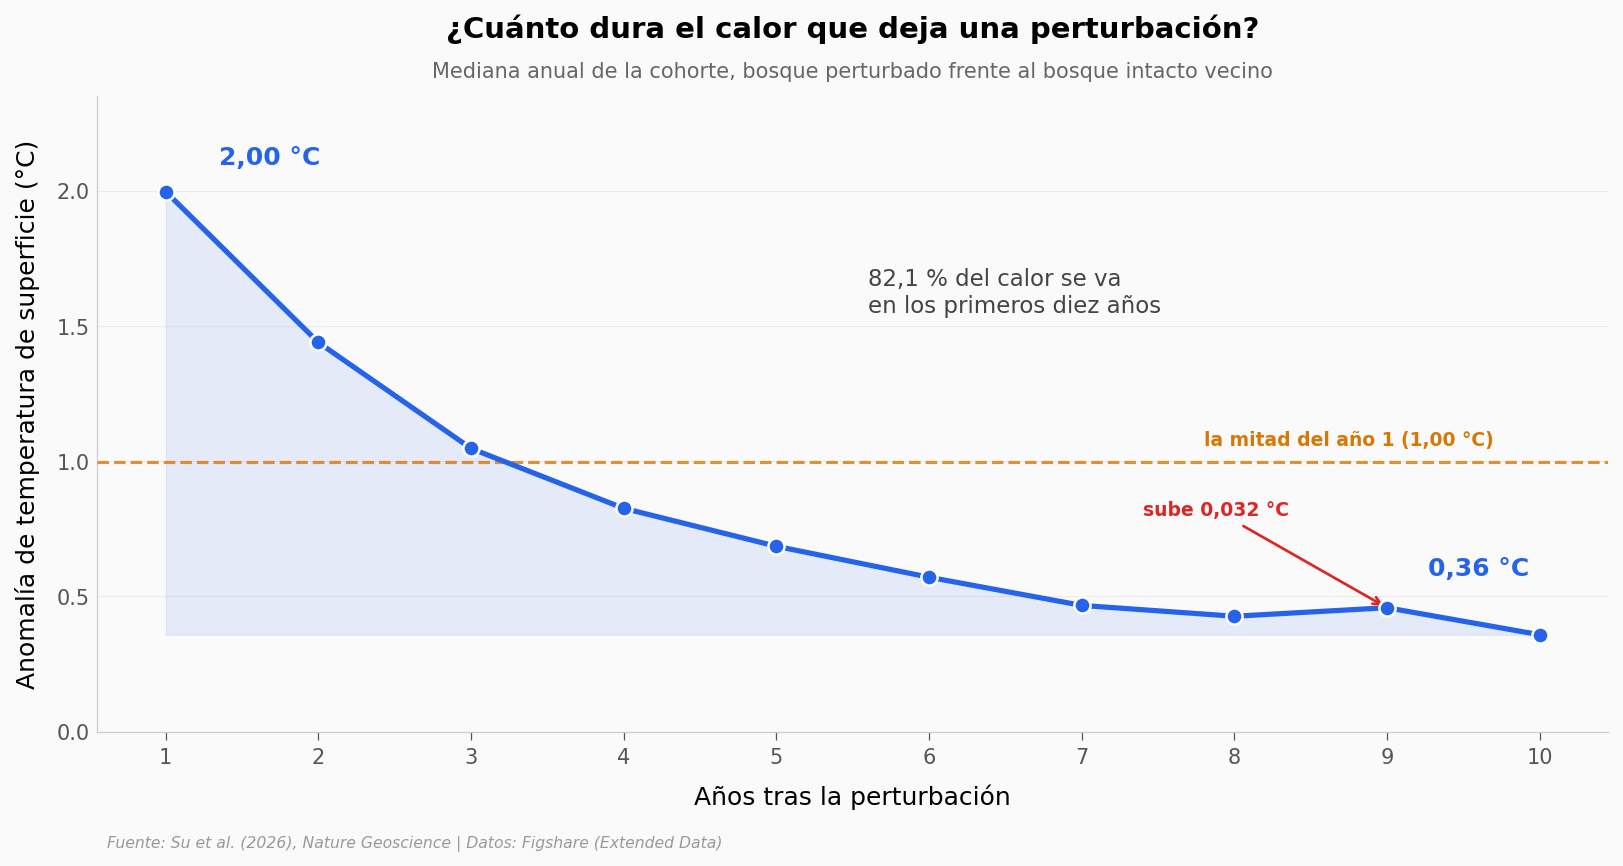

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = recup.anios_tras_perturbacion
y = recup.anomalia_lst_c
mitad = a1 / 2

ax.plot(x, y, color=COLOR_DATOS, linewidth=2.5, zorder=4)
ax.scatter(x, y, color=COLOR_DATOS, s=60, zorder=5,
           edgecolors='white', linewidths=1.2)
ax.fill_between(x, y, a10, color=COLOR_DATOS, alpha=0.10, zorder=2)

# Referencia: la mitad del calor del primer año
ax.axhline(y=mitad, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8, zorder=3)
ax.text(9.7, mitad + 0.06, f'la mitad del año 1 ({mitad:.2f} °C)'.replace('.', ','),
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', ha='right')

# Anotaciones de los dos extremos
ax.annotate(f'{a1:.2f} °C'.replace('.', ','), xy=(1, a1), xytext=(1.35, a1 + 0.10),
            fontsize=12, fontweight='bold', color=COLOR_DATOS)
ax.annotate(f'{a10:.2f} °C'.replace('.', ','), xy=(10, a10), xytext=(9.6, a10 + 0.22),
            fontsize=12, fontweight='bold', color=COLOR_DATOS, ha='center')

# El repunte del año 9 — la curva no es limpia
a8 = recup.loc[recup.anios_tras_perturbacion == 8, 'anomalia_lst_c'].iloc[0]
a9 = recup.loc[recup.anios_tras_perturbacion == 9, 'anomalia_lst_c'].iloc[0]
ax.annotate(f'sube {a9 - a8:.3f} °C'.replace('.', ','), xy=(9, a9), xytext=(7.4, a9 + 0.34),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

ax.text(5.6, 1.55, f'{disipado_pct:.1f} % del calor se va\nen los primeros diez años'.replace('.', ','),
        fontsize=11, color='#444444', ha='left')

ax.set_xlabel('Años tras la perturbación')
ax.set_ylabel('Anomalía de temperatura de superficie (°C)')
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 2.35)
ax.set_title('¿Cuánto dura el calor que deja una perturbación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mediana anual de la cohorte, bosque perturbado frente al bosque intacto vecino',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/recuperacion_termica.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que llama la atención

El primer año se lleva el mordisco más grande: entre el año 1 y el año 2 se va cerca del 28 % del calor extra. Después la caída se aplana, y para cuando el bosque cumple una década de perturbado le queda 0,36 °C — un 18 % de lo que tenía.

La mitad del calentamiento cruza el umbral entre el año 3 y el año 4. Es decir: la mitad del problema se resuelve sola en menos de un lustro. La otra mitad va mucho más lenta: al llegar al año 10 todavía queda 0,36 °C, un 36 % de esa segunda mitad.

Y hay un detalle que no conviene barrer debajo de la alfombra: en el año 9 la anomalía **sube** 0,032 °C respecto al año 8. La trayectoria no es una curva limpia de manual. Con un punto por año y una sola cohorte, un repunte de esa magnitud es ruido esperable — pero está en los datos y se ve.

**Una aclaración sobre los dos números que ya aparecieron.** El 1,70 °C del abstract y los 2,00 °C de esta gráfica no son el mismo dato. El primero es el contraste general entre bosque perturbado y bosque intacto a 100-500 m del borde. El segundo es la mediana del primer año de esta cohorte concreta de recuperación, que arranca justo después del golpe. Distinto estadístico, distinto alcance, y por eso no se suman ni se sustituyen.

## ¿Y el tamaño del claro?

La intuición dice que un claro más grande debería calentarse más: menos sombra, más suelo expuesto, menos evaporación de las hojas. Los autores metieron el tamaño del parche al modelo junto con otros 20 predictores y midieron cuánto aporta cada uno con SHAP, una técnica que reparte la predicción del modelo entre sus variables.

Un aviso antes de mirar: **SHAP mide peso dentro del modelo, no causa en el mundo**. Que una variable cargue mucho significa que el modelo se apoya en ella para acertar, no que mover esa variable en un bosque real vaya a mover la temperatura.

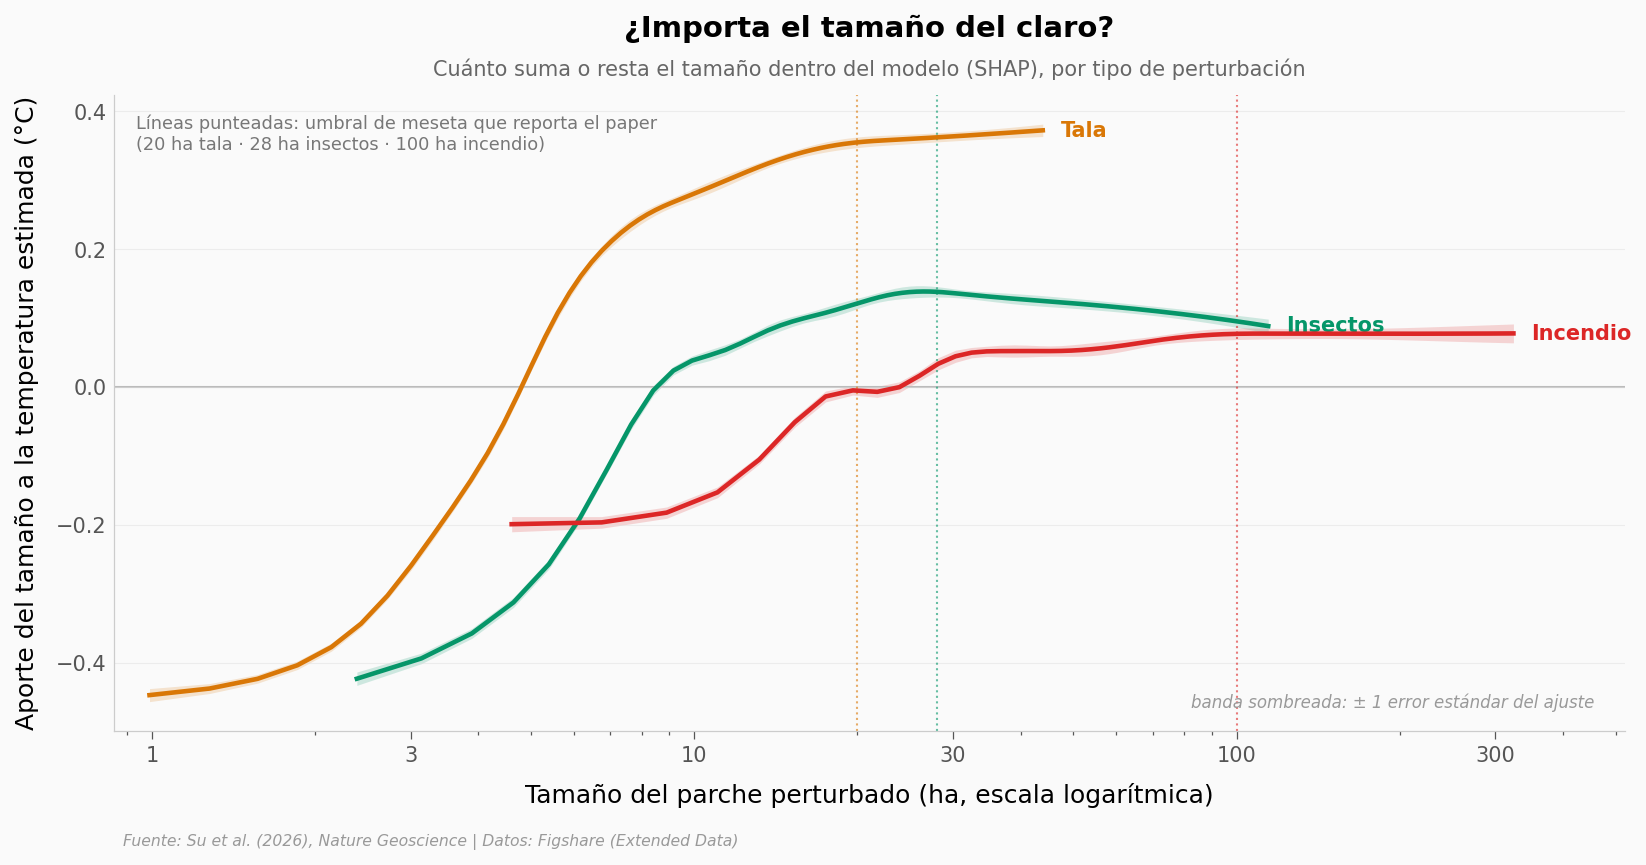

Rango total del aporte del tamaño: 0,82 °C (-0,45 a 0,37 °C)
Para comparar, la anomalía que el modelo estima es la del conjunto de
píxeles perturbados: 1,70 °C según el paper


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

for agente in ['Harvest', 'Insect', 'Fire']:
    d = shap_size[shap_size.agente == agente].sort_values('tamano_parche_ha')
    color = COLOR_AGENTE[agente]
    # Banda de +/- 1 error estandar del ajuste, calculada aqui a partir de shap_se_c
    ax.fill_between(d.tamano_parche_ha,
                    d.shap_lst_c - d.shap_se_c,
                    d.shap_lst_c + d.shap_se_c,
                    color=color, alpha=0.18, linewidth=0)
    ax.plot(d.tamano_parche_ha, d.shap_lst_c, color=color, linewidth=2.2, zorder=5)

    # Umbral de meseta reportado en la leyenda del paper (no recalculado)
    umbral = UMBRAL_MESETA_HA[agente]
    ax.axvline(x=umbral, color=color, linewidth=1, linestyle=':', alpha=0.6, zorder=2)

    # Etiqueta inline al final de cada curva
    ultima = d.iloc[-1]
    ax.text(ultima.tamano_parche_ha * 1.08, ultima.shap_lst_c,
            NOMBRE_AGENTE[agente], fontsize=10, color=color,
            fontweight='bold', va='center')

ax.axhline(y=0, color=COLOR_CONTEXTO, linewidth=1, zorder=1)

# Anotar los umbrales del paper una sola vez, con atribucion
ax.text(0.015, 0.97,
        'Líneas punteadas: umbral de meseta que reporta el paper\n'
        f"({UMBRAL_MESETA_HA['Harvest']} ha tala · {UMBRAL_MESETA_HA['Insect']} ha insectos · "
        f"{UMBRAL_MESETA_HA['Fire']} ha incendio)",
        transform=ax.transAxes, fontsize=8.5, color='#777777', va='top')
ax.text(0.98, 0.03, 'banda sombreada: ± 1 error estándar del ajuste',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

ax.set_xscale('log')
ax.set_xlim(0.85, 520)
ax.set_xticks([1, 3, 10, 30, 100, 300])
ax.set_xticklabels(['1', '3', '10', '30', '100', '300'])
ax.set_xlabel('Tamaño del parche perturbado (ha, escala logarítmica)')
ax.set_ylabel('Aporte del tamaño a la temperatura estimada (°C)')
ax.set_title('¿Importa el tamaño del claro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuánto suma o resta el tamaño dentro del modelo (SHAP), por tipo de perturbación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/shap_tamano_parche.png', dpi=200, bbox_inches='tight')
plt.show()

rango = shap_size.shap_lst_c.max() - shap_size.shap_lst_c.min()
print(f'Rango total del aporte del tamaño: {es(rango, 2)} °C '
      f'({es(shap_size.shap_lst_c.min(), 2)} a {es(shap_size.shap_lst_c.max(), 2)} °C)')
print('Para comparar, la anomalía que el modelo estima es la del conjunto de')
print(f'píxeles perturbados: {ANOMALIA_PAPER_C:.2f} °C según el paper'.replace('.', ','))

## Entonces el tamaño no es el que manda

Las curvas de tala y de incendio no se dan la vuelta, pero se aplanan pronto: la de tala acumula el 98 % de su recorrido antes de las 20 hectáreas y la de incendio prácticamente todo el suyo antes de las 100 — justo los umbrales de meseta que reporta el paper y que marcan las líneas punteadas. La de insectos hace algo distinto: sube hasta las 26 hectáreas y a partir de ahí baja — 26 es el punto más alto de la rejilla de tamaños que el paper exportó, o sea de los valores en los que alguien se molestó en evaluar la curva. Las tres se mueven dentro de una franja de menos de un grado en total — y la anomalía que el modelo trata de explicar es la del conjunto de píxeles perturbados, 1,70 °C, no los 2,00 °C de la cohorte del primer año. El tamaño pesa, pero no manda.

Hay un dato que reporta el paper y que ayuda a entender por qué: el parche perturbado **mediano** en Europa es de 1,19 hectáreas. Poco más de un campo de fútbol y medio. Con 1.425.501 eventos registrados en la cohorte, la perturbación europea típica no es el incendio de portada, es una mancha diminuta repetida un millón de veces. Ojo: ninguna de esas dos cifras está en los CSV que descargamos — las citamos del paper, no las replicamos aquí.

Si no es el tamaño, ¿qué es? El modelo tiene 21 predictores. Veamos a cuáles se agarra.

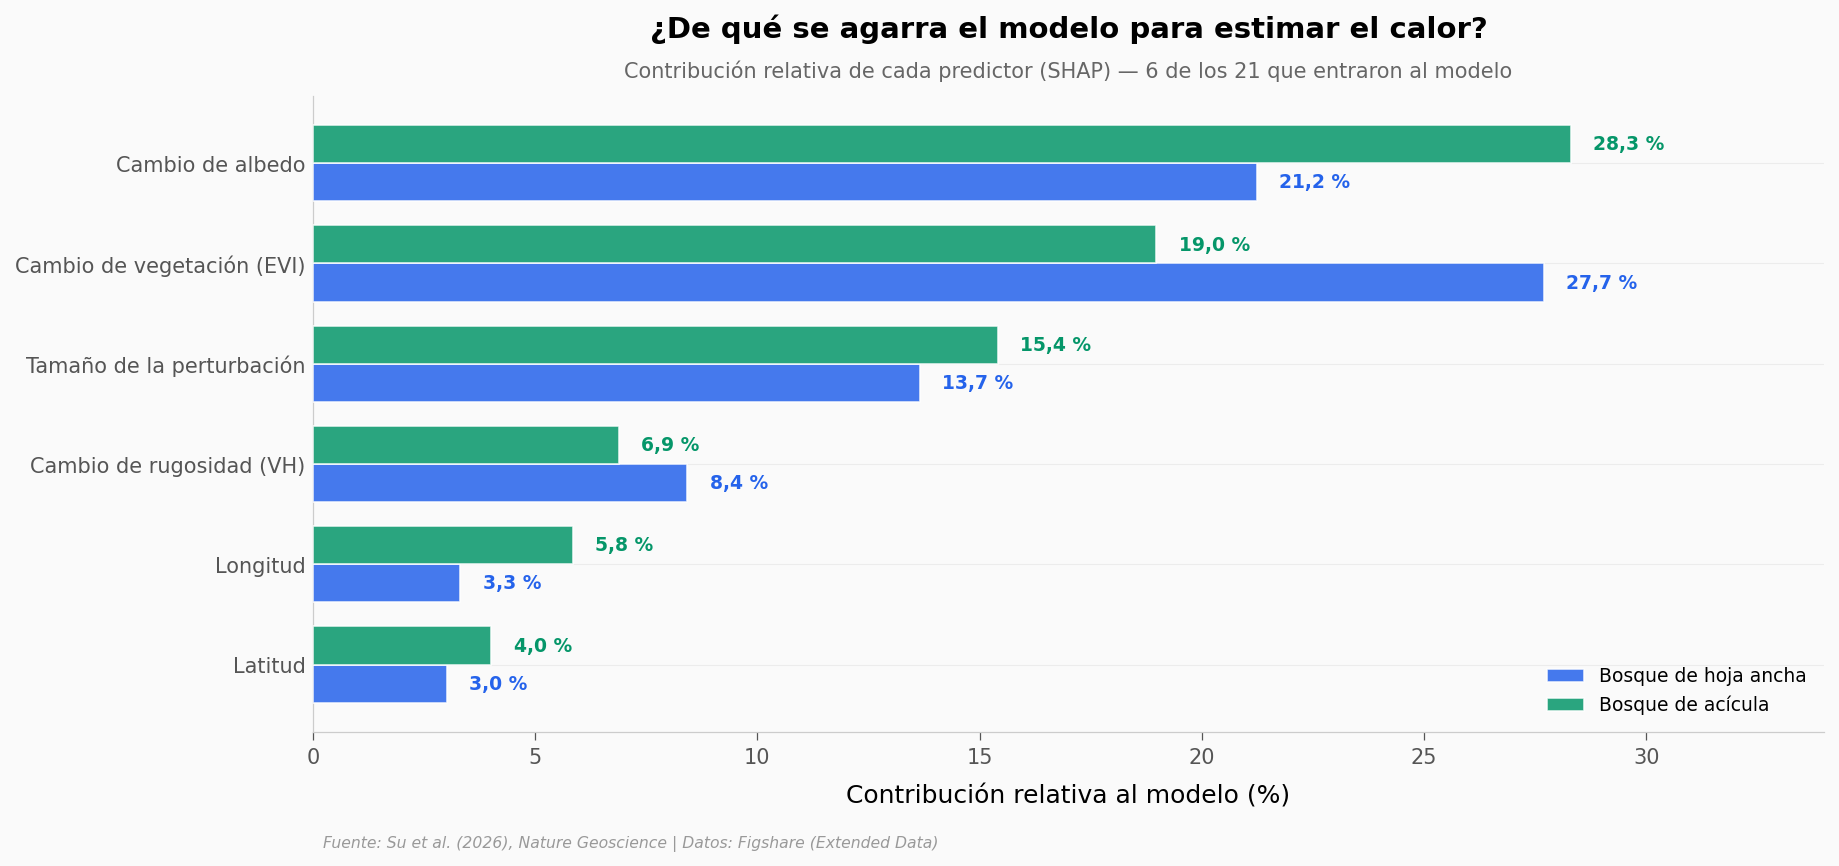

Hoja ancha  → lidera "Cambio de vegetación (EVI)" con 27,7 % | los 3 primeros suman 62,6 %
Acícula     → lidera "Cambio de albedo" con 28,3 % | los 3 primeros suman 62,7 %


In [4]:
# Top N predictores por contribucion relativa, ordenados por el promedio de ambos tipos
orden = (importancia.groupby('predictor_es').contribucion_relativa_pct
         .mean().sort_values(ascending=False).head(TOP_N_PREDICTORES).index.tolist())

TRAD = {
    'EVI change': 'Cambio de vegetación (EVI)',
    'Albedo change': 'Cambio de albedo',
    'Disturbance size': 'Tamaño de la perturbación',
    'Roughness change - VH': 'Cambio de rugosidad (VH)',
    'Roughness change - VV': 'Cambio de rugosidad (VV)',
    'Longitude': 'Longitud',
    'Latitude': 'Latitud',
    'Elevation': 'Altitud',
}

fig, ax = plt.subplots(figsize=(13, 5.5))
alto = 0.38
pos = np.arange(len(orden))

for i, (tipo, etiqueta, color) in enumerate([
        ('Broadleaf', 'Bosque de hoja ancha', COLOR_DATOS),
        ('Needleleaf', 'Bosque de acícula', COLOR_SECUNDARIO)]):
    d = importancia[importancia.tipo_bosque == tipo].set_index('predictor_es')
    vals = [d.loc[p, 'contribucion_relativa_pct'] for p in orden]
    offset = (0.5 - i) * alto
    ax.barh(pos + offset, vals, height=alto, color=color, alpha=0.85,
            edgecolor='white', linewidth=0.8, label=etiqueta, zorder=4)
    for y, v in zip(pos + offset, vals):
        ax.text(v + 0.5, y, f'{v:.1f} %'.replace('.', ','), va='center',
                fontsize=9, color=color, fontweight='bold')

ax.set_yticks(pos)
ax.set_yticklabels([TRAD.get(p, p) for p in orden], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Contribución relativa al modelo (%)')
ax.set_xlim(0, 34)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax.set_title('¿De qué se agarra el modelo para estimar el calor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Contribución relativa de cada predictor (SHAP) — 6 de los 21 que entraron al modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/contribucion_predictores.png', dpi=200, bbox_inches='tight')
plt.show()

NOMBRE_BOSQUE = {'Broadleaf': 'Hoja ancha', 'Needleleaf': 'Acícula'}
for tipo in ['Broadleaf', 'Needleleaf']:
    d = importancia[importancia.tipo_bosque == tipo].nlargest(3, 'contribucion_relativa_pct')
    lider = d.iloc[0]
    print(f'{NOMBRE_BOSQUE[tipo]:11s} → lidera "{TRAD.get(lider.predictor_es, lider.predictor_es)}" '
          f'con {es(lider.contribucion_relativa_pct, 1)} % | '
          f'los 3 primeros suman {es(d.contribucion_relativa_pct.sum(), 1)} %')

## El cambio de guardia

En los bosques de hoja ancha manda la pérdida de vegetación: el cambio en el índice EVI se lleva el 27,7 % de la contribución. En los de acícula — pinos, abetos, píceas — el primer puesto se lo lleva el cambio de albedo — cuánta luz devuelve la superficie en vez de absorberla, y cuánto cambió eso tras la perturbación — con el 28,3 %; y el EVI baja al segundo lugar.

Una lectura posible: cuando cae un pinar oscuro queda expuesto un suelo que devuelve la luz de otra manera, y ahí el albedo pesa. En un hayedo el reparto va más por la hoja que se perdió que por lo que quedó debajo. Es nuestra interpretación del reparto de predictores — el paper mide el peso, no el porqué.

Ojo con lo que esto significa y lo que no. El abstract del paper dice que en el calentamiento posterior a la perturbación **el peso principal recae** en la pérdida de vegetación y de estructura del dosel (el techo de hojas), y que de ahí la severidad emerge como el predictor más fuerte. Ojo: 'severidad' no es ninguna de las 21 columnas que descargamos — el reparto de la gráfica de arriba es el de esos 21 predictores, y ahí mandan el cambio de EVI y el de albedo. Eso es una lectura del modelo, no un experimento: nadie taló un pinar y otro no para comparar.

Ahora la pregunta que queda: los otros 18 predictores, ¿pintan algo?

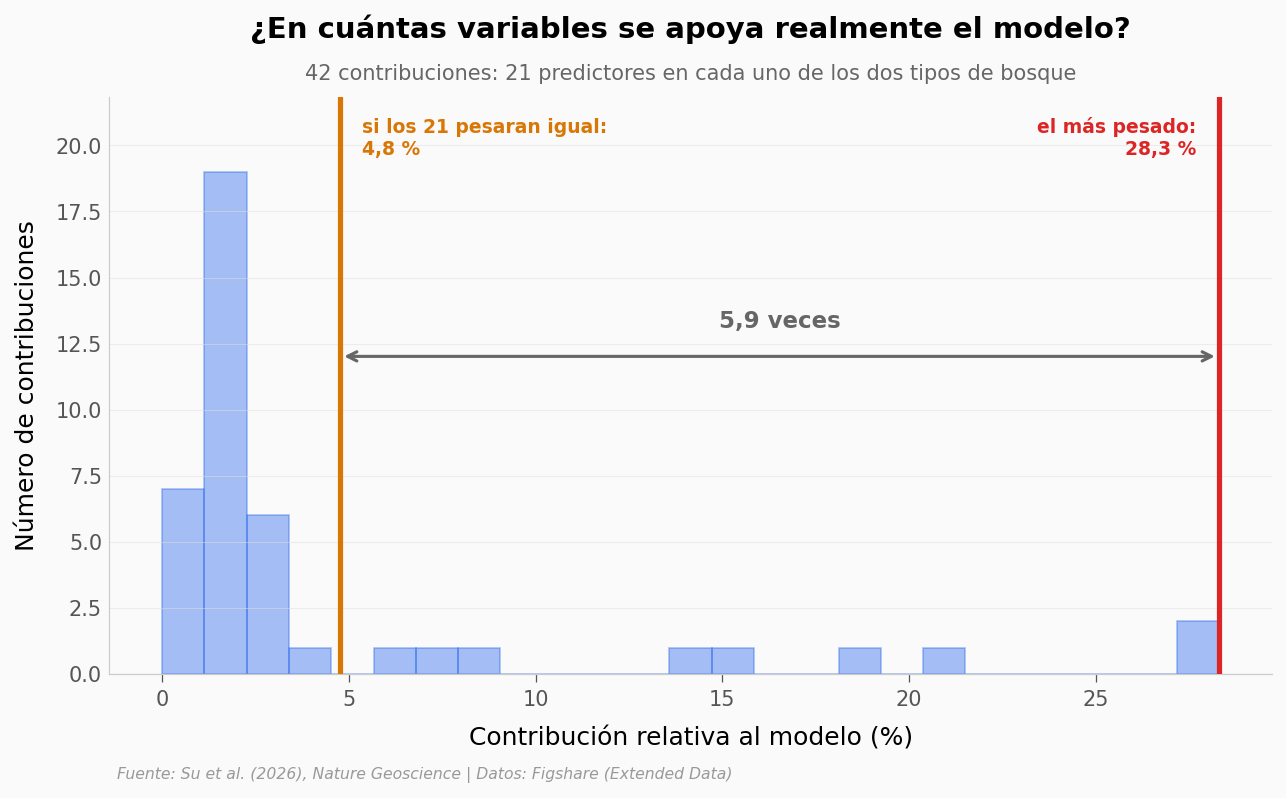

Mediana de contribución: 1,96 %   (IQR 1,29 – 3,24 %)
33 de las 42 contribuciones quedan por debajo del reparto igualitario de 4,76 %
  Hoja ancha  → los 3 primeros suman 62,6 %, los otros 18 se reparten 37,4 %
  Acícula     → los 3 primeros suman 62,7 %, los otros 18 se reparten 37,3 %


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = importancia.contribucion_relativa_pct.values
reparto_igual = 100 / importancia.predictor.nunique()   # si los 21 pesaran lo mismo
maximo = vals.max()

n, bins, patches = ax.hist(vals, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=reparto_igual, color=COLOR_REFERENCIA, linewidth=2.5, zorder=5)
ax.axvline(x=maximo, color=COLOR_ALERTA, linewidth=2.5, zorder=5)

ax.annotate('', xy=(maximo, y_max * 0.55), xytext=(reparto_igual, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((reparto_igual + maximo) / 2, y_max * 0.60,
        f'{maximo / reparto_igual:.1f} veces'.replace('.', ','),
        fontsize=11, color='#666666', ha='center', fontweight='bold')

ax.text(reparto_igual + 0.6, y_max * 0.90,
        f'si los 21 pesaran igual:\n{reparto_igual:.1f} %'.replace('.', ','),
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')
ax.text(maximo - 0.6, y_max * 0.90, f'el más pesado:\n{maximo:.1f} %'.replace('.', ','),
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='right')

ax.set_xlabel('Contribución relativa al modelo (%)')
ax.set_ylabel('Número de contribuciones')
ax.set_title('¿En cuántas variables se apoya realmente el modelo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '42 contribuciones: 21 predictores en cada uno de los dos tipos de bosque',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/concentracion_predictores.png', dpi=200, bbox_inches='tight')
plt.show()

bajo_reparto = (vals < reparto_igual).sum()
print(f'Mediana de contribución: {es(np.median(vals), 2)} %   '
      f'(IQR {es(np.percentile(vals, 25), 2)} – {es(np.percentile(vals, 75), 2)} %)')
print(f'{bajo_reparto} de las {len(vals)} contribuciones quedan por debajo '
      f'del reparto igualitario de {es(reparto_igual, 2)} %')
for tipo in ['Broadleaf', 'Needleleaf']:
    d = importancia[importancia.tipo_bosque == tipo].sort_values(
        'contribucion_relativa_pct', ascending=False)
    print(f'  {NOMBRE_BOSQUE[tipo]:11s} → los 3 primeros suman '
          f'{es(d.head(3).contribucion_relativa_pct.sum(), 1)} %, '
          f'los otros 18 se reparten {es(d.tail(18).contribucion_relativa_pct.sum(), 1)} %')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El bosque perturbado está 1,70 °C más caliente que el intacto a 100-500 m | ⚠️ | Verbatim del abstract. **No es reproducible en este notebook**: vive en un archivo de 676 MB que no descargamos. Lo citamos, no lo replicamos |
| Más del 82 % del calentamiento se disipa en diez años | ✅ | Nuestro cálculo da 82,07 % sobre la trayectoria de la cohorte (año 1: 2,00 °C → año 10: 0,36 °C). Réplica exacta de la afirmación del abstract |
| La caída es más fuerte al principio | ✅ | Del año 1 al 2 se va el 27,9 %. La mitad del calor cruza el umbral entre el año 3 y el 4 |
| La recuperación es monótona | ❌ | En el año 9 la anomalía sube 0,032 °C sobre el año 8. Es un solo punto y puede ser ruido, pero la curva no baja limpio |
| La pérdida de vegetación y dosel lleva el mayor peso | ⚠️ | Soportado **como importancia dentro del modelo** (SHAP), no como efecto causal medido. Diseño observacional sin asignación aleatoria |
| Los bosques de acícula se calientan más que los de hoja ancha | ⚠️ | Lo dice el abstract. Nuestros datos muestran que el **reparto de predictores** cambia entre los dos tipos (albedo manda en acícula, EVI en hoja ancha), pero no contienen las anomalías por tipo de bosque para comprobarlo |
| El tamaño del parche es un factor secundario | ⚠️ | Depende de cómo se mida. Su aporte a la temperatura estimada abarca de −0,45 a +0,37 °C, frente a la anomalía de 1,70 °C del paper. Pero en contribución relativa es el 3.º de 21 predictores (13,7 % hoja ancha, 15,4 % acícula) y forma parte del trío que se lleva el 63 %: secundario frente a EVI y albedo, no marginal |
| El modelo se apoya en pocas variables | ✅ | En ambos tipos de bosque los 3 predictores principales suman cerca del 63 % del total repartido entre 21 |

> **Limitaciones**
>
> - **Sin dispersión intra-año.** El script original del paper calcula los cuartiles de la anomalía, pero no los exportó al archivo de Extended Data. No hay barras de error posibles aquí, y no las inventamos.
> - **n = 10 es la trayectoria completa**, un punto por año de una sola cohorte. No es una muestra pequeña por accidente: es el diseño.
> - **El satélite mide superficie, no aire.** La temperatura de superficie terrestre se infiere de radiancia, no se toma con un termómetro clavado en el suelo.
> - **Diseño observacional.** El título del paper usa el verbo "regulan"; los datos permiten decir "el modelo le da el mayor peso a", no "esto causa aquello".
> - **Dos columnas idénticas en la fuente.** El archivo trae `base_LST_anomaly_C` y `adjusted_LST_anomaly_C` con exactamente los mismos valores. Usamos una sola; presentarlas como dos ajustes distintos sería inventar un análisis.
> - **Los umbrales de meseta (20, 28 y 100 ha) los reporta el paper en la leyenda de su Extended Data Fig. 1.** Son los que dibujamos y los que citamos. Cuando el texto habla de las 26 hectáreas donde la curva de insectos se da la vuelta, ése es un valor leído por nosotros sobre la rejilla descargada (pico en 26,45 ha), no el umbral del paper: los dos números miden cosas parecidas pero no son el mismo dato.

## Ahora tú

**1. ¿Cuántos años harían falta para que se fuera el 95 % del calor, y no el 82 %?**
La trayectoria se queda en el año 10 con 0,36 °C. Prueba ajustando un decaimiento exponencial a `recup` y extrapolando:
`np.polyfit(recup.anios_tras_perturbacion, np.log(recup.anomalia_lst_c), 1)`.
Ojo con lo que estás asumiendo: extrapolar más allá del año 10 es una apuesta, no una medición.

**2. ¿Cambia la historia si miras otro agente de perturbación?**
Cambia `AGENTE_FOCO` arriba y filtra `shap_size[shap_size.agente == AGENTE_FOCO]`. La curva del fuego está calculada hasta las 324 ha y la de tala solo hasta las 44 — son los extremos de la rejilla que exportó el paper, no el parche más grande que ardió en Europa. ¿La curva del fuego se aplana más tarde porque el fuego es distinto, o simplemente porque hay parches más grandes que medir?

**3. ¿Qué predictores quedan fuera del top 6?**
`importancia.sort_values('contribucion_relativa_pct').head(15)` te muestra la cola. Fíjate en cuáles son geográficos (latitud, longitud, altitud): si el modelo se apoyara mucho en ellos, estaría aprendiendo *dónde* está el bosque más que *qué le pasó*.

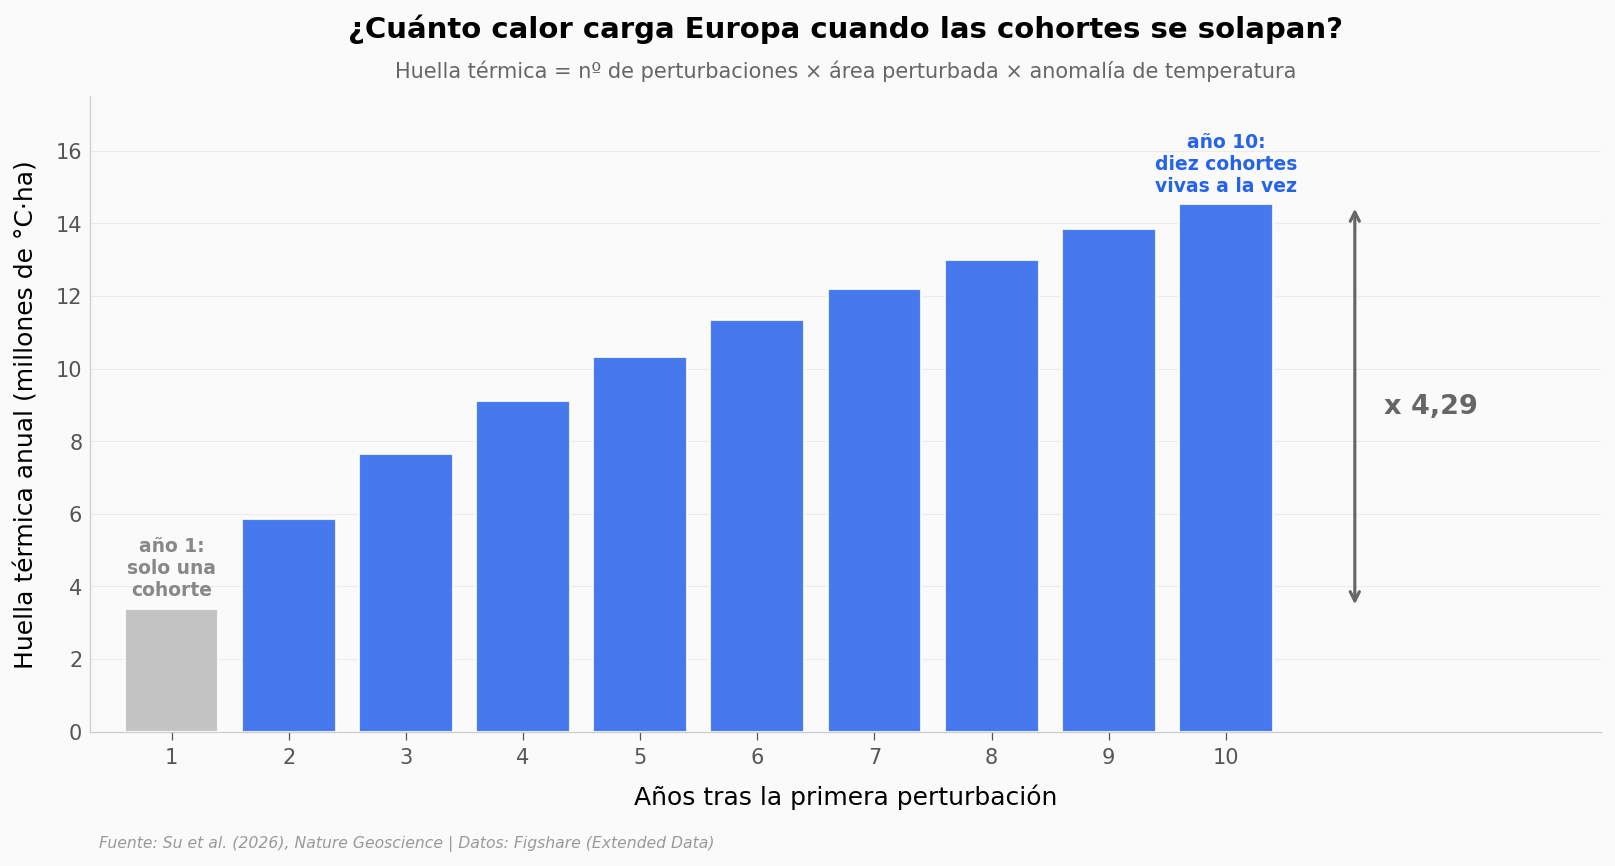

Huella anual en el año 1 (una cohorte)        : 3.387.805 °C·ha
Huella anual en el año 10 (diez cohortes)     : 14.518.807 °C·ha
Multiplicador por solapamiento                : 4,29x

Un detalle que vale la pena mirar dos veces:
  Acumulado de UNA cohorte en 10 años         : 14.034.591 °C·ha
  Diferencia con la huella anual del año 10   : 3,45 %
  Las dos cifras casi coinciden, y no es casualidad: sumar diez cohortes
  de edades 1 a 10 en un mismo año da lo mismo que seguir una cohorte
  durante diez años, siempre que el ritmo de perturbación no cambie.
  El 3,45 % que sobra dice justamente eso: el residuo entre las dos series
  crece cada año (0 -> 484.216 °C·ha), o sea que el ritmo NO fue constante.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: una cohorte se enfría en diez años, pero cada año se perturba bosque
# nuevo. ¿Cuánto calor carga Europa a la vez cuando hay diez cohortes vivas?
#
# Huella térmica = nº de perturbaciones x área perturbada x anomalía de temperatura.
# La definición es del propio paper (leyenda de Extended Data Fig. 3).

fig, ax = plt.subplots(figsize=(13, 5.5))

x = total_anual.anio
tf = total_anual.huella_termica_total_anual_grados_ha / 1e6
mult = tf.iloc[-1] / tf.iloc[0]

colores = [COLOR_DATOS] * len(x)
colores[0] = COLOR_CONTEXTO
ax.bar(x, tf, color=colores, alpha=0.85, edgecolor='white', linewidth=1, zorder=4)

ax.annotate('', xy=(11.1, tf.iloc[0]), xytext=(11.1, tf.iloc[-1]),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(11.35, (tf.iloc[0] + tf.iloc[-1]) / 2, f'x {mult:.2f}'.replace('.', ','),
        fontsize=13, color='#666666', fontweight='bold', va='center')

ax.text(1, tf.iloc[0] + 0.35, 'año 1:\nsolo una\ncohorte', fontsize=9,
        color='#888888', ha='center', fontweight='bold')
ax.text(10, tf.iloc[-1] + 0.35, 'año 10:\ndiez cohortes\nvivas a la vez', fontsize=9,
        color=COLOR_DATOS, ha='center', fontweight='bold')

ax.set_xticks(range(1, 11))
ax.set_xlim(0.3, 13.2)
ax.set_ylim(0, 17.5)
ax.set_xlabel('Años tras la primera perturbación')
ax.set_ylabel('Huella térmica anual (millones de °C·ha)')
ax.set_title('¿Cuánto calor carga Europa cuando las cohortes se solapan?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Huella térmica = nº de perturbaciones × área perturbada × anomalía de temperatura',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/huella_termica.png', dpi=200, bbox_inches='tight')
plt.show()

acumulada_una = recup.huella_termica_acumulada_grados_ha.iloc[-1]
anual_diez    = total_anual.huella_termica_total_anual_grados_ha.iloc[-1]
print(f'Huella anual en el año 1 (una cohorte)        : '
      f'{es(total_anual.huella_termica_total_anual_grados_ha.iloc[0])} °C·ha')
print(f'Huella anual en el año 10 (diez cohortes)     : {es(anual_diez)} °C·ha')
print(f'Multiplicador por solapamiento                : '
      f'{mult:.2f}x'.replace('.', ','))
print()
print('Un detalle que vale la pena mirar dos veces:')
print(f'  Acumulado de UNA cohorte en 10 años         : {es(acumulada_una)} °C·ha')
print(f'  Diferencia con la huella anual del año 10   : '
      f'{(anual_diez / acumulada_una - 1) * 100:.2f} %'.replace('.', ','))
print('  Las dos cifras casi coinciden, y no es casualidad: sumar diez cohortes')
print('  de edades 1 a 10 en un mismo año da lo mismo que seguir una cohorte')
print('  durante diez años, siempre que el ritmo de perturbación no cambie.')
print('  El 3,45 % que sobra dice justamente eso: el residuo entre las dos series')
print('  crece cada año (0 -> 484.216 °C·ha), o sea que el ritmo NO fue constante.')

## Fuentes

**Paper**: [Disturbance characteristics and forest properties regulate surface warming and recovery across Europe](https://doi.org/10.1038/s41561-026-02071-5)  
*Nature Geoscience, 2026-08-25 · paywall*

**Dataset canónico**: [Code and data used in "Disturbance characteristics and forest properties regulate surface warming and recovery across Europe"](https://doi.org/10.6084/m9.figshare.31147237)  
*Figshare — Source Data de las Extended Data Figs. 1-3 y los scripts R que las generan*

**Referencias citadas**: [The European Forest Disturbance Atlas: a forest disturbance monitoring system using the Landsat archive](https://doi.org/10.5194/essd-17-2373-2025) — *Earth System Science Data*, el inventario de perturbaciones que usa el paper

*14 afirmaciones del notebook verificadas contra estas fuentes*